<a href="https://colab.research.google.com/github/dayuun1/ai-systems/blob/lab1/%22pipeline_task_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна 1. Загальний пайплайн навчання.

В цій лабораторній роботі студенти тренують моделі машинного навчання
на базі простих регресій: лінійна, логістична, поліноміальна.
Ознайомлюються з базовими поняттями: спліт та  нормалізація даних, захист протікання даних (data leakage),
чистка, логування.

Працюємо в Google Colab.


## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [ ]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [ ]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [ ]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі ПІСЛЯ, викликаючи `set_seed()`. Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [ ]:
numbers = list(range(10))  # список для shuffle

val1 = random.randint(1, 100)
random.shuffle(numbers)
print(f"Спроба 1: число = {val1}, список = {numbers}")

val2 = random.randint(1, 100)
random.shuffle(numbers)
print(f"Спроба 2: число = {val2}, список = {numbers}")

set_seed()
print("Seed зафіксовано:", SEED)

set_seed()
val_after1 = random.randint(1, 100)
numbers1 = list(range(10))
random.shuffle(numbers1)
print(f"Спроба 1: число = {val_after1}, список = {numbers1}")

set_seed()
val_after2 = random.randint(1, 100)
numbers2 = list(range(10))
random.shuffle(numbers2)
print(f"Спроба 2: число = {val_after2}, список = {numbers2}")


Спроба 1: число = 47, список = [1, 5, 6, 7, 8, 0, 3, 9, 2, 4]
Спроба 2: число = 61, список = [5, 0, 4, 3, 6, 2, 7, 1, 8, 9]
Seed зафіксовано: 42
Спроба 1: число = 82, список = [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Спроба 2: число = 82, список = [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]


До `set_seed()`: генератор використовує системний час, тому щоразу видає різні випадкові числа та інший порядок у списку.
Після `set_seed()`: початковий стан фіксується, тому алгоритм видає однакові числа та ідентично перемішує список.

`set_seed()` потрібен для відтворюваності результатів у тестах і розрахунках.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [ ]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cuda
Використовуємо     : cpu
GPU: Tesla T4


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [ ]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [ ]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [ ]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)

print(identity.ndim)
print(random_ints.ndim)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[0 6 4]
 [2 2 9]
 [9 8 6]]
2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [ ]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [ ]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [ ]:
df = pd.DataFrame({
    "student": ["Даня", "Богдан", "Андрій", "Оля", "Саша", "Рома"],
    "score": [95, 72, 88, 65, 91, 80]
})

top = df[df["score"] > 80].sort_values(by="score", ascending=False)
print(top)

  student  score
0    Даня     95
4    Саша     91
2  Андрій     88


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [ ]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"
def assign_grade(score):
    if score >= 90:
        return "A"
    elif score >= 75:
        return "B"
    else:
        return "C"

df["grade"] = df["score"].apply(assign_grade)
print(df)


  student  score grade
0    Даня     95     A
1  Богдан     72     C
2  Андрій     88     B
3     Оля     65     C
4    Саша     91     A
5    Рома     80     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [ ]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t, zeros_t.shape, zeros_t.dtype)
print(sevens_t, sevens_t.shape, sevens_t.dtype)


tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.Size([2, 3]) torch.float32
tensor([[7, 7, 7],
        [7, 7, 7]]) torch.Size([2, 3]) torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [ ]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)

tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [ ]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print("shape:", from_list.shape, "| dtype:", from_list.dtype, "| ndim:", from_list.ndim)
print(random_t)
print("shape:", random_t.shape, "| dtype:", random_t.dtype, "| ndim:", random_t.ndim)


tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2]) | dtype: torch.int64 | ndim: 2
tensor([[0.1478, 0.7411, 0.0197],
        [0.5355, 0.7409, 0.2898],
        [0.5173, 0.1023, 0.8754]])
shape: torch.Size([3, 3]) | dtype: torch.float32 | ndim: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [ ]:
n = 5.0

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

auto_grad = x.grad.item()
analytical_grad = 2 * n

print(f"Автоматичний градієнт: {auto_grad}")
print(f"Аналітичний градієнт: {analytical_grad}")
print(f"Чи збігаються: {auto_grad == analytical_grad}")


Автоматичний градієнт: 10.0
Аналітичний градієнт: 10.0
Чи збігаються: True


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [ ]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()

    with torch.no_grad():
        x -= lr * x.grad

    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

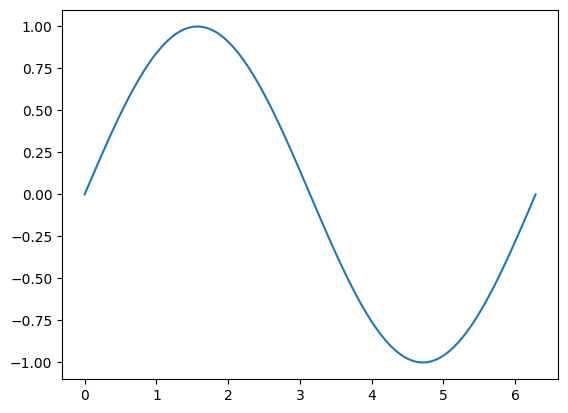

In [ ]:
xs = np.linspace(0, 2 * np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

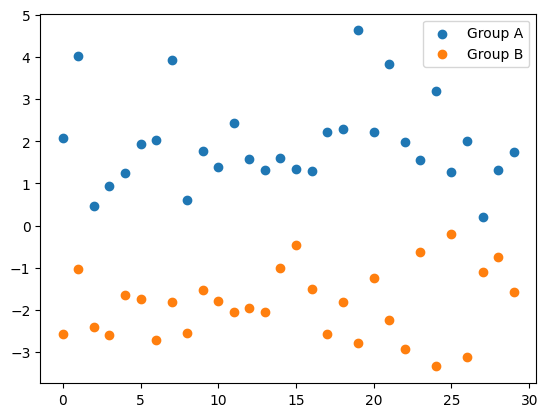

In [ ]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.scatter(range(len(group_a)), group_a, color="C0", label="Group A")
plt.scatter(range(len(group_b)), group_b, color="C1", label="Group B")

plt.legend()
plt.show()

---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [ ]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

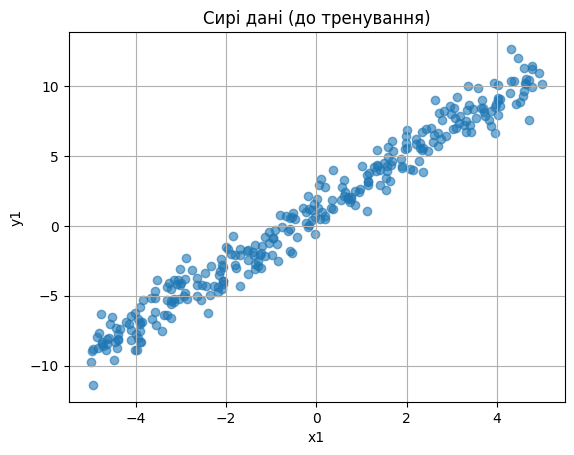

In [ ]:
plt.scatter(x1, y1, alpha=0.6)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.grid(True)
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15) — простий зріз тензора за індексами, без `Dataset`/`DataLoader`. Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [ ]:
indices = torch.randperm(TASK1_N)
x1_shuffled = x1[indices]
y1_shuffled = y1[indices]

train_size = int(0.70 * TASK1_N)
val_size = int(0.15 * TASK1_N)

x_train1 = x1_shuffled[:train_size]
y_train1 = y1_shuffled[:train_size]

x_val1 = x1_shuffled[train_size:train_size + val_size]
y_val1 = y1_shuffled[train_size:train_size + val_size]

x_test1 = x1_shuffled[train_size + val_size:]
y_test1 = y1_shuffled[train_size + val_size:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [ ]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=17.435926  w=1.7695 (true 2.0)  b=-0.4989 (true 1.0)
epoch   30  loss=1.090293  w=2.0205 (true 2.0)  b=0.9752 (true 1.0)
epoch   60  loss=1.084787  w=2.0225 (true 2.0)  b=1.0393 (true 1.0)
epoch   90  loss=1.084777  w=2.0225 (true 2.0)  b=1.0421 (true 1.0)
epoch   99  loss=1.084776  w=2.0225 (true 2.0)  b=1.0422 (true 1.0)


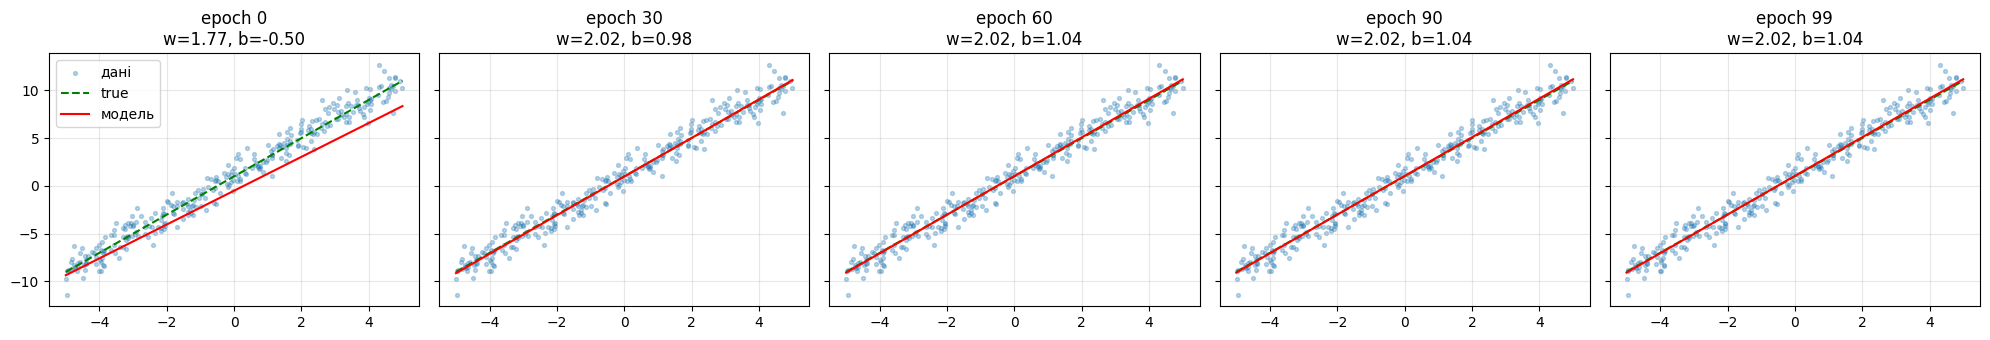

In [ ]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом (за зразком Завдання 1) і натренуй лінійну регресію
за тим самим патерном — спліт, цикл навчання, перевірка на test. Організуй код тренування у логічні перевикористовувані функції.

### Сценарій: Вплив годин практики водіння на успішність складання практичного іспиту

* **$x$ (ознака):** Кількість годин практичного водіння з інструктором (діапазон від 10 до 50 годин).
* **$y$ (цільова змінна для лінійної регресії):** Бали за якість/впевненість водіння за шкалою від 0 до 100 (де 70+ балів — успішне складання).
* **$w = 1.8$:** Кожна додаткова година за кермом дає системний приріст навичок та додає в середньому ~1.8 бала до підсумкової оцінки.
* **$b = 15.0$:** Базовий мінімум (15 балів) — мінімальне розуміння правил чи випадкові успішні дії навіть за мінімального досвіду.
* **Логістична регресія:** Цільова мітка $1$ (іспит складено), якщо бал $\ge 70$, і $0$ (не складено), якщо бал $< 70$.

Кількість годин за кермом впливає на спробу успішної здачі, а також на це впливає хвилювання, випадкові помилки та злі екзаменатори (в житомирькому сервісному центрі такі є). Тому додато Гауссів шум.

In [ ]:
import torch.nn as nn

TRUE_W = 1.8
TRUE_B = 15.0
N = 300

x = torch.empty(N, 1).uniform_(10, 50)
noise = 4.0 * torch.randn(N, 1)  # людський фактор
y = TRUE_W * x + TRUE_B + noise

indices = torch.randperm(N)
x_shuffled, y_shuffled = x[indices], y[indices]

train_size = int(0.70 * N)
val_size = int(0.15 * N)

x_train, y_train = x_shuffled[:train_size], y_shuffled[:train_size]
x_val, y_val = x_shuffled[train_size:train_size + val_size], y_shuffled[train_size:train_size + val_size]
x_test, y_test = x_shuffled[train_size + val_size:], y_shuffled[train_size + val_size:]

def train_linear_model(x_tr, y_tr, x_v, y_v, in_features=1, epochs=500, lr=0.001):
    model = nn.Linear(in_features, 1)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        preds = model(x_tr)
        loss = criterion(preds, y_tr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        v_loss = criterion(model(x_v), y_v).item()
    return model, v_loss

model_lin, val_loss = train_linear_model(x_train, y_train, x_val, y_val, lr=0.05)

model_lin.eval()
with torch.no_grad():
    test_loss = nn.MSELoss()(model_lin(x_test), y_test).item()

print(f"Знайдені параметри: w = {model_lin.weight.item():.4f}, b = {model_lin.bias.item():.4f}")
print(f"Test MSE Loss: {test_loss:.4f}")

Знайдені параметри: w = 2.1107, b = 4.3882
Test MSE Loss: 32.3839


**Вправа 21.** Візьми свій пайплайн із з Вправи 20 і
розшир його до **поліноміальної** та **логістичної** регресії:

- **Поліноміальна регресія**: додай ознаки $x^2$, $x^3$ (об'єднай через
  `torch.cat`, наприклад `torch.cat([x, x**2, x**3], dim=1)`), модель тепер
  `nn.Linear(3, 1)` замість `nn.Linear(1, 1)`. MSE-loss і цикл навчання
  лишаються без змін.
- **Логістична регресія**: зміни задачу на класифікацію (два класи), заміни
  `nn.MSELoss()` на [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)
  — вихід моделі тепер логіт, а не пряме передбачення. Метрика — accuracy
  (`(torch.sigmoid(logits) > 0.5)`), а не MSE.

Навчи модель на своїх або
нових даних.

In [ ]:

# Поліноміальна регресія
x_poly_train = torch.cat([x_train, x_train**2, x_train**3], dim=1)
x_poly_val = torch.cat([x_val, x_val**2, x_val**3], dim=1)
x_poly_test = torch.cat([x_test, x_test**2, x_test**3], dim=1)

p_mean = x_poly_train.mean(dim=0, keepdim=True)
p_std = x_poly_train.std(dim=0, keepdim=True)

x_poly_train_norm = (x_poly_train - p_mean) / p_std
x_poly_val_norm = (x_poly_val - p_mean) / p_std
x_poly_test_norm = (x_poly_test - p_mean) / p_std

model_poly, _ = train_linear_model(
    x_poly_train_norm, y_train, x_poly_val_norm, y_val, in_features=3, epochs=600, lr=0.01
)

model_poly.eval()
with torch.no_grad():
    poly_loss = nn.MSELoss()(model_poly(x_poly_test_norm), y_test).item()
print(f"[Поліноміальна] Test MSE Loss: {poly_loss:.4f}")

# Логістична регресія (склав / не склав іспит)
y_cls_train = (y_train >= 70.0).float()
y_cls_val = (y_val >= 70.0).float()
y_cls_test = (y_test >= 70.0).float()

model_log = nn.Linear(1, 1)
criterion_bce = nn.BCEWithLogitsLoss()
optimizer_log = torch.optim.Adam(model_log.parameters(), lr=0.01)

x_mean, x_std = x_train.mean(), x_train.std()
x_tr_norm = (x_train - x_mean) / x_std
x_te_norm = (x_test - x_mean) / x_std

for epoch in range(600):
    model_log.train()
    logits = model_log(x_tr_norm)
    loss = criterion_bce(logits, y_cls_train)

    optimizer_log.zero_grad()
    loss.backward()
    optimizer_log.step()

model_log.eval()
with torch.no_grad():
    test_logits = model_log(x_te_norm)
    preds = (torch.sigmoid(test_logits) > 0.5).float()
    acc = (preds == y_cls_test).float().mean().item()

print(f"[Логістична] Test Accuracy: {acc * 100:.2f}%")

[Поліноміальна] Test MSE Loss: 3611.5334
[Логістична] Test Accuracy: 97.78%
